# Q-learning swing-up of the unbalanced disk

Tabular Q-learning that learns to swing the disk up and balance it at the top, trained in simulation (`UnbalancedDiskDiscrete`) and deployed on the real setup (`UnbalancedDiskExp` via `runExp.py`).

**Notebook layout**
1. Imports
2. Wrappers & helpers (`UnbalancedDiskResetWrapper`, `Discretize_obs`, `argmax`, `roll_mean`)
3. `Qlearn` — the training loop (epsilon-greedy, decaying α, start-position curriculum, moving-average checkpointing)
4. Exploration-schedule plot
5. Training
6. Training-reward plot
7. Evaluation (deterministic, fixed start at the bottom)


In [ ]:
#  Imports & global configuration
import sys
import os
import pickle
import time
import warnings
from collections import defaultdict, deque

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces, Wrapper

warnings.filterwarnings("ignore")

# --- path ---
sys.path.append(os.path.expanduser("~/src/swingup/q_learning"))
from UnbalancedDiskDiscrete import UnbalancedDisk

# Environment hyperparameters
DT              = 0.025   # simulation timestep (s)
UMAX            = 3.0     # maximum control voltage (V)
NVEC_ANGLE      = 120     # number of angle bins
NVEC_RPS        = 50      # number of angular-velocity bins

# Training hyperparameters 
NSTEPS          = 380_000 # total training steps
MAX_EP_STEPS    = 300     # max steps per episode (train & eval)
ALPHA           = 0.15    # initial learning rate
GAMMA           = 0.99    # discount factor
AVG_WINDOW      = 8       # moving-average window for checkpointing
CALLBACK_FREQ   = 5_000   # steps between optional callback calls

# Evaluation hyperparameters
NUM_EVAL_EPS    = 50      # number of greedy evaluation episodes
EVAL_SEED       = 0       # fixed seed for reproducibility
TOP_TOL         = 0.30    # angular tolerance for "at top" (rad, ~17°)
NUM_WATCH_EPS   = 3       # episodes to render visually

# Checkpoint
CHECKPOINT      = 'Q_learning_test_v1.pkl'

In [2]:
#  Environment wrappers & helper utilities
class UnbalancedDiskResetWrapper(gym.Wrapper):
    """Normalise ``reset()`` across Gymnasium versions.

    Older builds of the environment return only ``obs``; newer ones return
    ``(obs, info)``.  This wrapper always returns ``(obs, info)``.
    """

    def __init__(self, env):
        super().__init__(env)

    def reset(self, *, seed=None, options=None):
        try:
            obs, info = self.env.reset(seed=seed)
        except TypeError:
            obs, info = self.env.reset(), {}
        return obs, info


class Discretize_obs(gym.Wrapper):
    """Discretise ``[theta, omega]`` into a state tuple for tabular Q-learning.

    Angle discretisation uses a **non-uniform** grid that is fine near the top
    position (φ = 0) and coarser near the bottom (φ = ±π).  Angular velocity
    uses a uniform grid over the observation-space range.

    Parameters
    ----------
    env : gym.Env
        The wrapped environment.
    nvec : array-like of int
        ``[n_angle_ignored, n_omega]``.  The angle count is derived from the
        grid edges; only the omega count is read from this argument.
    fine_w : float
        Half-width (rad) of the fine-resolution zone around the top.
    fine_res : float
        Grid spacing (rad) inside the fine zone.
    coarse_res : float
        Grid spacing (rad) outside the fine zone.

    .. warning::
        ``discretize()`` must be identical in ``runExp.py``; a mismatch
        causes a silent state-space incompatibility between training and
        deployment.
    """

    def __init__(self, env, nvec, fine_w=0.40, fine_res=0.025, coarse_res=0.10):
        super().__init__(env)
        o = env.observation_space
        self.omega_low  = float(o.low[1])
        self.omega_high = float(o.high[1])
        self.n_omega    = int(np.array(nvec).flatten()[1])

        # Non-uniform angle edges: fine near top, coarse near bottom
        pos = (
            list(np.arange(0.0, fine_w,   fine_res))
            + list(np.arange(fine_w, np.pi, coarse_res))
            + [np.pi]
        )
        self.angle_edges = np.array(sorted(set([-e for e in pos] + pos)))
        self.n_angle = len(self.angle_edges) - 1
        self.observation_space = gym.spaces.MultiDiscrete([self.n_angle, self.n_omega])

    def discretize(self, observation):
        """Map a continuous ``[theta, omega]`` observation to a discrete bin tuple."""
        th = float(observation[0])
        om = float(observation[1])

        # Wrap theta so that 0 = top, ±π = bottom
        phi = (th % (2 * np.pi)) - np.pi
        a = int(np.clip(
            np.searchsorted(self.angle_edges, phi, side='right') - 1,
            0, self.n_angle - 1
        ))

        om = np.clip(om, self.omega_low, self.omega_high)
        b = int(np.clip(
            (om - self.omega_low) / (self.omega_high - self.omega_low) * self.n_omega,
            0, self.n_omega - 1
        ))
        return (a, b)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self.discretize(obs), reward, terminated, truncated, info

    def reset(self, *args, **kwargs):
        obs, info = self.env.reset()
        return self.discretize(obs), info


# Utility functions

def roll_mean(ar, start=2000, N=50):
    """Exponential moving average of array *ar*.

    Parameters
    ----------
    ar : np.ndarray
        Input signal.
    start : float
        Initial value of the accumulator.
    N : int
        Smoothing horizon; larger values produce a smoother output.

    Returns
    -------
    np.ndarray
        Same shape as *ar*.
    """
    s = 1 - 1 / N
    k = start
    out = np.zeros(ar.shape)
    for i, a in enumerate(ar):
        k = s * k + (1 - s) * a
        out[i] = k
    return out


def argmax(a):
    """Return the index of the maximum, breaking ties uniformly at random.

    Avoids the systematic bias of ``np.argmax``, which always picks the
    first maximum.
    """
    a = np.array(a)
    return np.random.choice(np.arange(len(a), dtype=int)[a == np.max(a)])

In [3]:
#  Tabular Q-learning
def Qlearn(env, nsteps=5000, nvec_angle=360, nvec_rps=30, callbackfeq=5000,
           alpha=0.15, gamma=0.99, avg_window=8,
           checkpoint_name='best_Qmat.pkl', callback=None):
    """Tabular Q-learning for the discrete unbalanced-disk environment.

    Learns a Q-table (``dict[(state, action)] -> float``) with
    epsilon-greedy exploration and a TD(0) update rule.

    Three quantities anneal over *nsteps*:

    .. code-block:: text

        epsilon        0.7·exp(-5z/nsteps) + 0.01,  floored at 0
                       → explore early, deterministic finish
        alpha_now      alpha·(1 - z/nsteps),          floored at 0.01
                       → large updates early, fine-tuning late
        start_scale    1 → 0.15
                       → curriculum: start anywhere early, near bottom late

    A warm start is attempted if *checkpoint_name* already exists on disk.
    The checkpoint is (over)written whenever the moving average of the last
    *avg_window* episode returns reaches a new all-time high, so the saved
    model reflects **consistent** performance rather than one lucky episode.

    Parameters
    ----------
    env : gym.Env
        Discretised, time-limited training environment.
    nsteps : int
        Total number of environment steps.
    nvec_angle : int
        Angle bins (informational; not used inside this function).
    nvec_rps : int
        Angular-velocity bins (informational; not used inside this function).
    callbackfeq : int
        How often (in steps) the optional *callback* is called.
    alpha : float
        Initial learning rate.
    gamma : float
        Discount factor.
    avg_window : int
        Number of recent episodes used for the moving-average checkpoint.
    checkpoint_name : str
        Path to the pickle file used for saving/loading the best Q-table.
    callback : callable or None
        Optional ``callback(Qmat, step, env)`` called every *callbackfeq* steps.

    Returns
    -------
    Qmat : dict
        Best Q-table found (by moving-average reward).
    ep_lengths_steps : np.ndarray
        Training step at which each episode ended.
    ep_lengths : np.ndarray
        Length (steps) of each episode.
    ep_rewards : np.ndarray
        Total undiscounted return of each episode.
    """
    Qmat = defaultdict(float)

    # Locate the TimeLimit wrapper to read _elapsed_steps after each episode
    env_time = env
    while not isinstance(env_time, gym.wrappers.TimeLimit):
        if hasattr(env_time, 'env'):
            env_time = env_time.env
        else:
            print("Warning: no gym.wrappers.TimeLimit found; _elapsed_steps unavailable.")
            break

    ep_lengths, ep_lengths_steps, ep_rewards = [], [], []
    obs, info = env.reset()
    current_episode_reward = 0.0
    ep_max_abs_th = 0.0
    best_avg_reward = -float('inf')
    best_Qmat_to_save = None
    recent_rewards = deque(maxlen=avg_window)

    # Warm start: load existing checkpoint if present
    if os.path.exists(checkpoint_name):
        try:
            with open(checkpoint_name, 'rb') as f:
                Qmat.update(pickle.load(f))
            print(f"Loaded initial Qmat from '{checkpoint_name}'; continuing training.")
        except Exception as e:
            print(f"Warning: could not load '{checkpoint_name}': {e}. Starting fresh.")
    else:
        print(f"No checkpoint at '{checkpoint_name}'; starting from an empty Qmat.")

    for z in range(nsteps):
        # Annealed exploration: decays to 0 so the final policy is deterministic
        eps       = (0.7 * np.exp(-5 * z / nsteps) + 0.01) * max(0.0, 1 - z / nsteps)
        # Annealed learning rate: large early (explore), small late (lock in)
        alpha_now = max(0.01, alpha * (1 - z / nsteps))
        # Curriculum: wide start distribution early -> near bottom-at-rest late
        env.unwrapped.start_scale = max(0.15, 1 - z / nsteps)

        # Epsilon-greedy action selection
        if np.random.uniform() < eps:
            action = env.action_space.sample()
        else:
            action = argmax([Qmat[(obs, i)] for i in range(env.action_space.n)])

        obs_new, reward, terminated, truncated, info = env.step(action)
        ep_max_abs_th = max(ep_max_abs_th, abs(env.unwrapped.th))
        current_episode_reward += reward

        if callback and z % callbackfeq == 0:
            callback(Qmat, z, env)

        if terminated or truncated:
            # Terminal state: no next state to bootstrap from
            Qmat[(obs, action)] += alpha_now * (reward - Qmat[(obs, action)])

            ep_len = env_time._elapsed_steps   # read BEFORE reset clears it
            ep_lengths.append(ep_len)
            ep_lengths_steps.append(z)
            ep_rewards.append(current_episode_reward)
            recent_rewards.append(current_episode_reward)
            obs, info = env.reset()

            # Checkpoint when the moving average hits a new high
            if len(recent_rewards) == avg_window:
                running_avg = float(np.mean(recent_rewards))
                if running_avg > best_avg_reward:
                    best_avg_reward = running_avg
                    best_Qmat_to_save = Qmat.copy()
                    try:
                        with open(checkpoint_name, 'wb') as fpkl:
                            pickle.dump(best_Qmat_to_save, fpkl)
                        print(
                            f"#################################\n"
                            f" NEW BEST AVG REWARD (last {avg_window} ep): "
                            f"{running_avg:.2f}, saved to '{checkpoint_name}'\n"
                            f"#################################"
                        )
                    except Exception as e:
                        print(f"Error saving Qmat: {e}")

            max_deg = np.degrees(ep_max_abs_th)
            if   terminated:       tag = "FELL/SPUN"
            elif max_deg > 190:    tag = f"OVERSHOOT +{max_deg - 180:.0f} deg"
            elif max_deg > 165:    tag = "balanced ~top"
            else:                  tag = "stalled below"
            print(
                f"step {z+1:>7} | len {ep_len:>3} | "
                f"reward {current_episode_reward:>8.1f} | "
                f"max {max_deg:>4.0f} deg (top=180) | {tag}"
            )
            current_episode_reward = 0.0
            ep_max_abs_th = 0.0

        else:
            # Non-terminal: TD(0) bootstrap update
            best_next = max(Qmat[(obs_new, a)] for a in range(env.action_space.n))
            td_error = reward + gamma * best_next - Qmat[(obs, action)]
            Qmat[(obs, action)] += alpha_now * td_error
            obs = obs_new

    # Return the best checkpoint (fall back to in-memory copy or current table)
    if os.path.exists(checkpoint_name):
        try:
            with open(checkpoint_name, 'rb') as f:
                Qmat_final = pickle.load(f)
            print(f"Loading final best Qmat (avg reward {best_avg_reward:.2f}) from '{checkpoint_name}'.")
            return Qmat_final, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)
        except Exception as e:
            print(f"Error loading final Qmat: {e}. Returning current Qmat.")
    elif best_Qmat_to_save is not None:
        print("No checkpoint file found; returning best in-memory Qmat.")
        return best_Qmat_to_save, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)
    else:
        print("No best Qmat was saved; returning the current Qmat.")

    return Qmat, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)

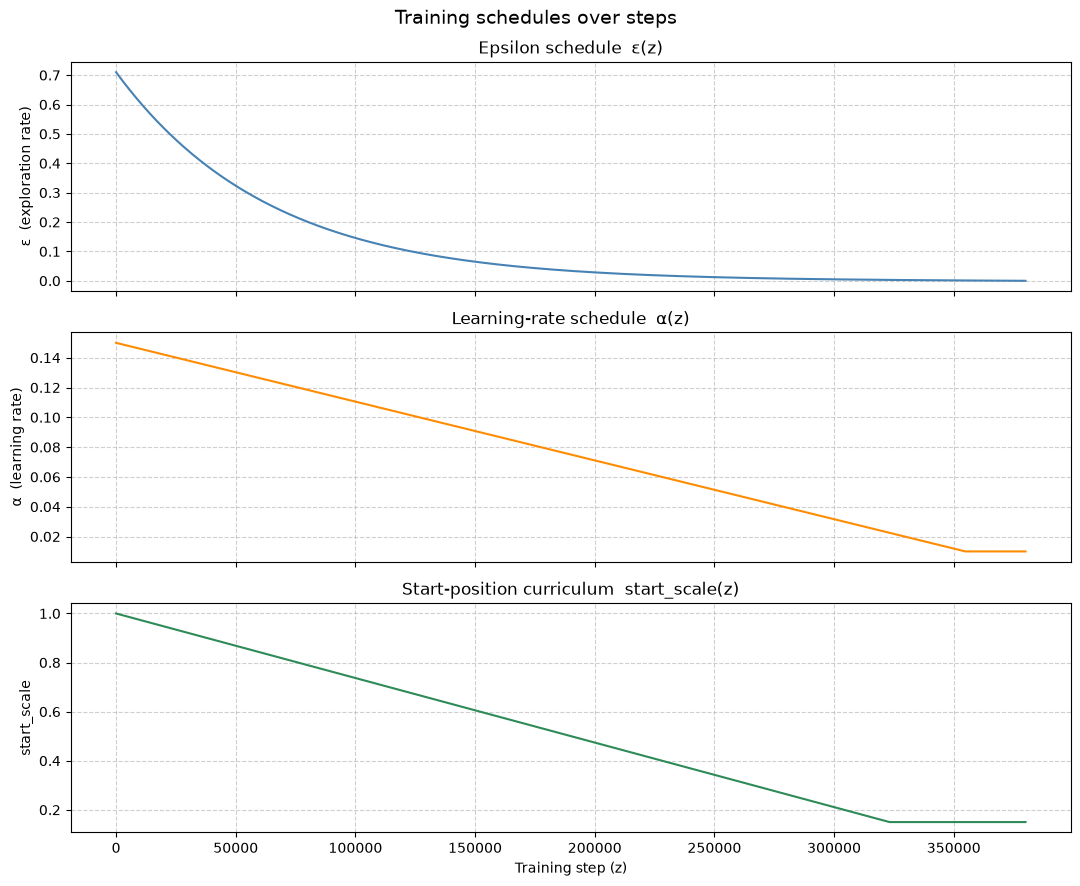

In [4]:
#  Training schedule visualisation
#  Shows how epsilon, alpha, and start_scale evolve over NSTEPS.

z_arr         = np.arange(NSTEPS)
eps_arr       = (0.7 * np.exp(-5 * z_arr / NSTEPS) + 0.01) * np.maximum(0.0, 1 - z_arr / NSTEPS)
alpha_arr     = np.maximum(0.01, ALPHA * (1 - z_arr / NSTEPS))
start_arr     = np.maximum(0.15, 1 - z_arr / NSTEPS)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
fig.suptitle("Training schedules over steps", fontsize=14)

axes[0].plot(z_arr, eps_arr, color='steelblue')
axes[0].set_ylabel("ε  (exploration rate)")
axes[0].set_title("Epsilon schedule  ε(z)")
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(z_arr, alpha_arr, color='darkorange')
axes[1].set_ylabel("α  (learning rate)")
axes[1].set_title("Learning-rate schedule  α(z)")
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].plot(z_arr, start_arr, color='seagreen')
axes[2].set_ylabel("start_scale")
axes[2].set_title("Start-position curriculum  start_scale(z)")
axes[2].set_xlabel("Training step (z)")
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [5]:
#  Training
print("\n--- START TRAINING ---")

env_train = UnbalancedDisk(dt=DT, umax=UMAX, render_mode=None)
env_train = UnbalancedDiskResetWrapper(env_train)
env_train = gym.wrappers.TimeLimit(env_train, max_episode_steps=MAX_EP_STEPS)
env_train = Discretize_obs(env_train, nvec=[NVEC_ANGLE, NVEC_RPS])

Qmat_trained, ep_lengths_steps, ep_lengths, ep_rewards = Qlearn(
    env_train,
    nsteps=NSTEPS,
    nvec_angle=NVEC_ANGLE,
    nvec_rps=NVEC_RPS,
    callbackfeq=CALLBACK_FREQ,
    alpha=ALPHA,
    gamma=GAMMA,
    avg_window=AVG_WINDOW,
    checkpoint_name=CHECKPOINT,
)
env_train.close()

# Verify the checkpoint was written successfully
if os.path.exists(CHECKPOINT):
    print(f"\nCheckpoint '{CHECKPOINT}' found on disk.")
    with open(CHECKPOINT, 'rb') as f:
        _check = pickle.load(f)
    print(f"Loaded for verification: {len(_check)} Q-table entries.")
else:
    print(f"\nWarning: checkpoint '{CHECKPOINT}' not found on disk.")


--- START TRAINING ---
Loaded initial Qmat from 'Q_learning_DATA_v66.pkl'; continuing training.
step     300 | len 300 | reward    -73.8 | max  121 deg (top=180) | stalled below
step     600 | len 300 | reward   -108.0 | max   48 deg (top=180) | stalled below
step     900 | len 300 | reward    -93.9 | max   46 deg (top=180) | stalled below
step    1200 | len 300 | reward    -95.2 | max  101 deg (top=180) | stalled below
step    1500 | len 300 | reward    -91.7 | max  138 deg (top=180) | stalled below
step    1800 | len 300 | reward    -97.5 | max   57 deg (top=180) | stalled below
step    2100 | len 300 | reward    -94.8 | max  125 deg (top=180) | stalled below
#################################
 NEW BEST AVG REWARD (last 8 ep): -94.02, saved to 'Q_learning_DATA_v66.pkl'
#################################
step    2400 | len 300 | reward    -97.3 | max   94 deg (top=180) | stalled below
step    2700 | len 300 | reward    -96.7 | max   58 deg (top=180) | stalled below
step    3000 | len 3

Last 10 episode rewards: [346.19062222 184.05610785 560.85609679  63.12777383 221.97669996
 190.74028538  71.85329651 927.62202862 435.23199326 100.88840735]


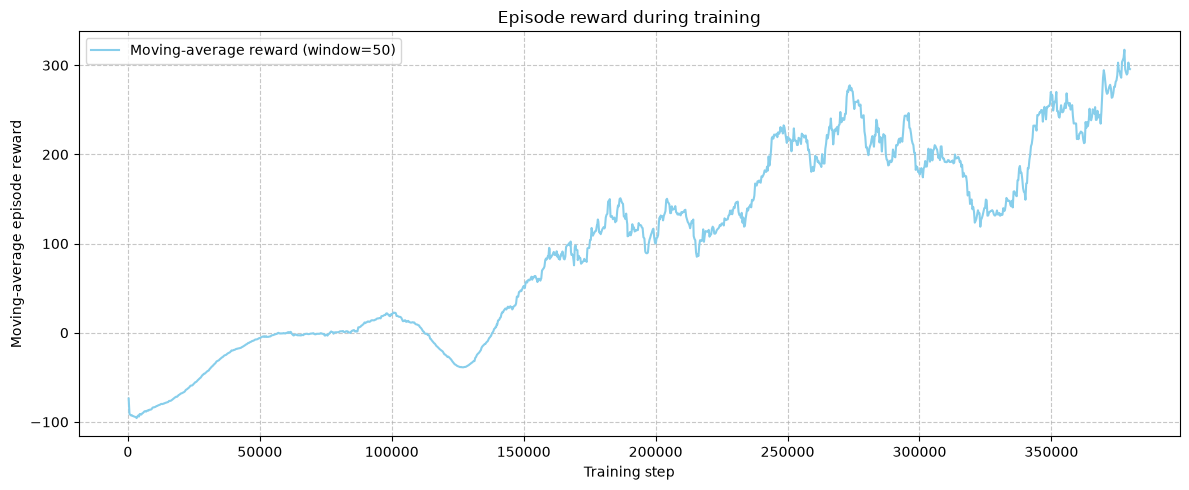

In [6]:
#  Training reward curve

N_ROLLING = 50
rolled = [
    np.mean(ep_rewards[max(0, i - N_ROLLING + 1): i + 1])
    for i in range(len(ep_rewards))
]

print(f"Last 10 episode rewards: {ep_rewards[-10:]}")

plt.figure(figsize=(12, 5))
plt.plot(ep_lengths_steps, rolled,
         label=f"Moving-average reward (window={N_ROLLING})", color='skyblue')
plt.xlabel("Training step")
plt.ylabel("Moving-average episode reward")
plt.title("Episode reward during training")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [7]:
#  Greedy evaluation with best checkpoint

print("\n--- START EVALUATION WITH BEST MODEL ---")

def make_eval_env(render_mode):
    """Build the evaluation environment stack (identical to training, no curriculum)."""
    e = UnbalancedDisk(dt=DT, umax=UMAX, render_mode=render_mode)
    e = UnbalancedDiskResetWrapper(e)
    e = gym.wrappers.TimeLimit(e, max_episode_steps=MAX_EP_STEPS)
    e = Discretize_obs(e, nvec=[NVEC_ANGLE, NVEC_RPS])
    return e


def greedy_action(Qmat, obs, n):
    """Select the greedy action deterministically (first argmax, no tie-breaking)."""
    return int(np.argmax([Qmat.get((obs, a), 0.0) for a in range(n)]))


def run_episode(env, Qmat, start=(0.0, 0.0), render=False, fps=30):
    """Run one greedy episode from a fixed start state.

    Parameters
    ----------
    env : gym.Env
        Discretised evaluation environment.
    Qmat : dict
        Q-table to act greedily with respect to.
    start : tuple of float
        ``(theta, omega)`` initial state forced before ``env.reset()``.
    render : bool
        Whether to call ``env.render()`` each step.
    fps : int
        Target rendering frame rate (used only when *render* is True).

    Returns
    -------
    total_r : float
        Undiscounted episode return.
    steps : int
        Episode length in steps.
    top_frac : float
        Fraction of steps spent within *TOP_TOL* of the top position.
    ended_at_top : bool
        Whether the final state was within *TOP_TOL* of the top.
    """
    base = env.unwrapped
    base.set_th, base.set_omega = float(start[0]), float(start[1])
    obs, info = env.reset()
    base.set_th, base.set_omega = None, None   # restore default reset behaviour

    total_r, steps, done, top_steps = 0.0, 0, False, 0
    while not done:
        action = greedy_action(Qmat, obs, env.action_space.n)
        obs, reward, terminated, truncated, info = env.step(action)
        total_r += reward
        steps   += 1
        done     = terminated or truncated

        err_top = abs(((base.th - np.pi + np.pi) % (2 * np.pi)) - np.pi)
        if err_top < TOP_TOL:
            top_steps += 1

        if render:
            env.render()
            time.sleep(1 / fps)

    err_top_final = abs(((base.th - np.pi + np.pi) % (2 * np.pi)) - np.pi)
    ended_at_top  = err_top_final < TOP_TOL
    return total_r, steps, top_steps / max(steps, 1), ended_at_top


# Load best Q-table
best_Qmat = None
if os.path.exists(CHECKPOINT):
    with open(CHECKPOINT, 'rb') as f:
        best_Qmat = pickle.load(f)
    print(f"Loaded best Qmat from '{CHECKPOINT}' ({len(best_Qmat)} entries).")
else:
    print(f"Error: checkpoint '{CHECKPOINT}' not found. Run training first.")

if best_Qmat is not None:
    START = (0.0, 0.0)   # fixed start: disk at rest at the bottom

    # ── Statistical evaluation (no render) ──────────────────
    np.random.seed(EVAL_SEED)
    env_stats = make_eval_env(render_mode=None)
    rewards, lengths, toptime, ended = [], [], [], []
    for _ in range(NUM_EVAL_EPS):
        r, l, ft, et = run_episode(env_stats, best_Qmat, start=START)
        rewards.append(r); lengths.append(l); toptime.append(ft); ended.append(et)
    env_stats.close()

    rewards  = np.array(rewards)
    lengths  = np.array(lengths)
    toptime  = np.array(toptime)

    print(f"\n--- EVALUATION RESULTS ({NUM_EVAL_EPS} greedy episodes, fixed start at bottom) ---")
    print(f"Reward      : mean {rewards.mean():8.2f} | std {rewards.std():7.2f} | "
          f"median {np.median(rewards):8.2f} | min {rewards.min():8.2f} | max {rewards.max():8.2f}")
    print(f"Length      : mean {lengths.mean():8.1f} | min {int(lengths.min())} | max {int(lengths.max())}")
    print(f"Time at top : mean {100*toptime.mean():5.1f}%   ← primary quality metric")
    print(f"Success     : {100*np.mean(ended):5.1f}% of episodes ended at the top")

    # ── Visual evaluation (rendered) ────────────────────────
    np.random.seed(EVAL_SEED)
    env_watch = make_eval_env(render_mode='human')
    for i in range(NUM_WATCH_EPS):
        r, l, ft, et = run_episode(env_watch, best_Qmat, start=START, render=True)
        print(f"Watch episode {i+1}: length={l}, reward={r:.2f}, time-at-top={100*ft:.0f}%")
    env_watch.close()

else:
    print("No best Qmat available for evaluation.")


--- START EVALUATION WITH BEST MODEL ---
Loaded best Qmat from 'Q_learning_DATA_v66.pkl' (48720 entries).

--- EVALUATION RESULTS (50 greedy episodes, fixed start at bottom) ---
Reward      : mean   254.11 | std  202.27 | median   188.93 | min     5.61 | max   883.56
Length      : mean    300.0 | min 300 | max 300
Time at top : mean  24.1%   ← primary quality metric
Success     :  74.0% of episodes ended at the top
Watch episode 1: length=300, reward=629.82, time-at-top=44%
Watch episode 2: length=300, reward=146.63, time-at-top=15%
Watch episode 3: length=300, reward=106.17, time-at-top=4%
